# NYC Yellow Taxi Fleet Deployment and Revenue Optimization
### Notebook 02: Predictive modeling and prescriptive deployment analysis

**Course:** DSS142P | **Group 1:** Abad, Aguirre, Galit, Ibañez, Risma, Vicente

**Input:** `data/NYC_Taxi_ABT.parquet`, built by `01_abt.ipynb` (3,757,895 valid trips, Jan–Nov 2025)
**Run order:** `01_abt.ipynb` → this notebook

## Business context

New York City yellow taxi drivers earn only while a passenger is on board, and not every dollar a passenger pays stays with the driver. Each trip carries pass-through charges: the NYS congestion surcharge ($2.50), the MTA tax ($0.50), the improvement surcharge ($1.00), the airport fee ($1.75), and, since **January 5, 2025**, the MTA Congestion Relief Zone fee ($0.75 per yellow-taxi trip in Manhattan's Central Business District). Because these charges are flat per trip, they take a larger share of short, low-fare trips: about 31% of gross revenue on fares under $10, versus about 6% on fares of $40 or more (`01_abt.ipynb`, §6).

How much a driver keeps per occupied hour also depends on **where** and **when** they pick up passengers. Some zones and hours produce longer, better-paying trips, while traffic congestion stretches trip time without raising the fare proportionally. A fleet that positions its drivers well can earn more from the same driving hours.

## Business question and problem

**Business question.** *How can the fleet operator optimize shift scheduling and zone positioning to maximize driver hourly earnings and fleet revenue in the face of 2025 congestion fees?*

**Problem.** The fleet needs to know which pickup zones, days and hours to prioritize for driver deployment to maximize **net revenue per occupied driving hour**, and how congestion fees, trip length, fare level and traffic conditions affect that revenue efficiency.

**Output.** A decision-support model that predicts net revenue per occupied hour for each pickup zone × day × hour, converted into a **ranked deployment table**, a **fee-based fare and trip-length rule**, and **congestion thresholds** for deprioritizing zones.

| Item | Definition |
|---|---|
| Unit of analysis | Pickup zone × date × pickup hour, aggregated from trips |
| Target | `net_revenue_per_hour` = Σ net revenue ÷ Σ occupied minutes × 60, per zone-hour |
| Net revenue | Gross fare total − (CBD fee + congestion surcharge + airport fee + MTA tax + improvement surcharge) − tolls (ABT decision D1) |

## Analytical questions

1. **AQ1: Shift scheduling and zone positioning.** Which day-of-week and pickup-hour combinations should the fleet prioritize for driver deployment based on trip demand and revenue generated per occupied driving hour, and how does this vary across pickup zones?
2. **AQ2: Congestion-fee impact and thresholds.** To what extent do 2025 congestion fees reduce gross trip revenue across different fare tiers and pickup zones, and what trip-length thresholds or minimum fare should be applied to guide drivers to optimal zone-positioning to reduce revenue loss?
3. **AQ3: Congestion tipping points.** At what levels of traffic congestion do pickup zones begin to show lower net take per occupied driving hour, and which zones should the fleet deprioritize when congestion becomes too costly?

| AQ | Method | Output (section) |
|---|---|---|
| AQ1 | Champion model predictions per zone × day × hour, combined with expected demand | Ranked deployment table (§8.1) |
| AQ2 | Grouped analysis of fee share and net $/hr by fare tier, trip-length tier and zone (trip-level ABT) | Minimum-fare / trip-length rule and highest-burden zones (§8.2) |
| AQ3 | Champion model response to lagged traffic speed, overall and per zone | Speed thresholds and zones to deprioritize (§8.3) |

## Methodology

**Approach:** supervised regression + prescriptive ranking, following the comparative structure of Kankanamge et al. (2019), which compares XGBoost with SVR and a neural network on large-scale taxi data.

1. **Data (§2–3).** Load the validated ABT, confirm its structure, and explore the target by hour, day, zone, demand and traffic.
2. **Aggregation and features (§4).** Aggregate trips to zone × date × hour; build lagged demand, speed and fee-share features. **Leakage rule:** only information available before the hour is used as a predictor.
3. **Validation design (§5).** Expanding-window monthly folds (train on all earlier months, validate on the next month) are used for tuning. October–November 2025 is held out as the final test period and used once.
4. **One procedure for every model (§6).** Naive baseline, XGBoost, SVR and neural network all follow: tune on the folds → refit on all pre-test data → evaluate once on the test period. Preprocessing is fit inside the training data only.
5. **Evaluation (§7).** MAE (primary), RMSE and R²; ranking metrics (overall and within-hour Spearman, Precision@10); a day-level bootstrap confidence interval for each model's improvement over the baseline; and errors by segment (peak/off-peak, trip volume).
6. **Champion selection (§7).** Lowest test MAE, provided its improvement over the baseline is supported by the confidence interval; ranking metrics as supporting evidence.
7. **Interpretation and prescription (§8).** SHAP explanations of the champion, then the AQ1–AQ3 outputs.

### Changes from FA2

| FA2 issue | Fix in this version |
|---|---|
| ABT code, ABT file and model inputs were three different versions | Single rebuilt ABT (`01_abt.ipynb`) with documented findings and checks |
| XGBoost refit on train + validation; other models were not | One procedure for all models, including the baseline |
| Single validation split; MAE rose from validation to test | Expanding-window monthly folds |
| Spearman reported for XGBoost only; no ranking metric for dispatch | Spearman, within-hour Spearman and Precision@10 for every model |
| No uncertainty on the gain over the baseline | Day-level bootstrap confidence intervals |
| Feature importance presented as recommendations | Ranked deployment table, fee rule and congestion thresholds |
| Errors reported only as overall averages | Segment-level error analysis |
| SVR trained on a 25,000-row subsample (47 min) | Kernel-approximated SVR on the full training data |

## 1. Setup

In [189]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_start = time.perf_counter()

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from sklearn.model_selection import ParameterSampler

import warnings
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVR

# ---- Paths ----
DATA_DIR = Path("../data")
ABT_PATH = DATA_DIR / "NYC_Taxi_ABT.parquet"
ZONES_PATH = DATA_DIR / "taxi_zone_lookup.csv"
FIG_DIR = Path("../reports/figures")
TABLE_DIR = Path("../reports/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---- Reproducibility ----
RANDOM_STATE = 42

# ---- Validation design (see Methodology) ----
TEST_START = pd.Timestamp("2025-10-01")   # Oct–Nov 2025: final test period, used once
VALIDATION_MONTHS = [6, 7, 8, 9]          # each fold trains on all earlier months, validates on this one

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

def save_fig(fig, name):
    """Save a figure to reports/figures for use in the write-up."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

for p in [ABT_PATH, ZONES_PATH, FIG_DIR, TABLE_DIR]:
    print(f"{'✓' if p.exists() else '✗ MISSING'}  {p}")

✓  ../data/NYC_Taxi_ABT.parquet
✓  ../data/taxi_zone_lookup.csv
✓  ../reports/figures
✓  ../reports/tables


## 2. Load and validate the ABT
The ABT was validated in `01_abt.ipynb`; these checks confirm the file loaded here is that same, complete version.

In [190]:
abt = pd.read_parquet(ABT_PATH)
print(f"ABT: {len(abt):,} rows × {abt.shape[1]} columns | "
      f"{abt.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")

EXPECTED_ROWS = 3_757_895  # output of 01_abt.ipynb §8
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
required = ["tpep_pickup_datetime", "PULocationID", "pickup_hour", "day_of_week", "is_weekend",
            "duration_min", "speed_mph", "trip_distance", "fare_amount", "gross_revenue",
            "total_fees", "congestion_fees", "tolls_amount", "tip_amount", "net_revenue",
            "net_revenue_ex_tip", "net_revenue_per_hour", "fee_impact_pct",
            "congestion_fee_pct", "pickup_date", "pickup_month", "fare_tier", "trip_length_tier"]

recomputed_target = abt["net_revenue"] / abt["duration_min"] * 60
is_cat = lambda col: isinstance(abt[col].dtype, pd.CategoricalDtype)

checks = {
    "Row count matches 01_abt output":     len(abt) == EXPECTED_ROWS,
    "All required columns present":        set(required).issubset(abt.columns),
    "No missing values":                   abt.isna().sum().sum() == 0,
    "Pickups within Jan–Nov 2025":         abt["tpep_pickup_datetime"].between("2025-01-01", "2025-12-01").all(),
    "Target matches its formula":          np.allclose(recomputed_target, abt["net_revenue_per_hour"]),
    "Day order kept (Mon → Sun)":          is_cat("day_of_week") and list(abt["day_of_week"].cat.categories) == DAY_ORDER,
    "Tiers kept as ordered categories":    is_cat("fare_tier") and is_cat("trip_length_tier"),
}
results = pd.Series(checks, name="passed")
display(results.to_frame())
assert results.all(), f"Failed: {list(results[~results].index)}"
print("ABT validated ✓")

ABT: 3,757,895 rows × 37 columns | 0.73 GB in memory


,passed
Row count matches 01_abt output,True
All required columns present,True
No missing values,True
Pickups within Jan–Nov 2025,True
Target matches its formula,True
Day order kept (Mon → Sun),True
Tiers kept as ordered categories,True


ABT validated ✓


In [191]:
monthly = (abt.groupby("pickup_month")
              .agg(trips=("net_revenue", "size"),
                   avg_net_per_hour=("net_revenue_per_hour", "mean"))
              .round(2))
monthly["role"] = np.where(monthly.index >= TEST_START.month, "TEST (held out)",
                  np.where(monthly.index.isin(VALIDATION_MONTHS), "validation fold", "training only"))
monthly

,trips,avg_net_per_hour,role
pickup_month,,,
1,308589,95.87,training only
2,315088,93.20,training only
3,364210,94.57,training only
4,348376,92.34,training only
5,384718,90.09,training only
6,365964,92.41,validation fold
7,328019,91.57,validation fold
8,292101,91.55,validation fold
9,358195,88.48,validation fold


In [192]:
zones = pd.read_csv(ZONES_PATH)
display(zones.head())

abt_zones = abt["PULocationID"].unique()
unnamed = set(abt_zones) - set(zones["LocationID"])
print(f"Pickup zones in ABT: {len(abt_zones)} | zones without a name: {len(unnamed)}")
print("\nPickup zones by borough:")
print(zones[zones["LocationID"].isin(abt_zones)]["Borough"].value_counts().to_string())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Pickup zones in ABT: 258 | zones without a name: 0

Pickup zones by borough:
Borough
Queens           69
Manhattan        67
Brooklyn         61
Bronx            43
Staten Island    17
EWR               1


## 3. Exploratory data analysis

**Rule:** EDA uses only the pre-test period (Jan–Sep 2025). The Oct–Nov test period stays unseen until final evaluation, so that it cannot influence modeling choices.

These are trip-level views. Zone-hour views (the unit of analysis) follow the aggregation in §4.

In [193]:
from matplotlib.colors import LinearSegmentedColormap

eda = abt[abt["pickup_date"] < TEST_START]
n_days = eda["pickup_date"].nunique()

print(f"EDA period: {eda['pickup_date'].min():%b %d} – {eda['pickup_date'].max():%b %d, %Y}")
print(f"EDA trips:  {len(eda):,} over {n_days} days")
print(f"Held out:   {len(abt) - len(eda):,} trips (Oct–Nov)")

# Chart colors: one fixed palette for every figure in this notebook
BLUE, ORANGE = "#2a78d6", "#eb6834"   # series 1, series 2
INK = "#0b0b0b"                        # text and reference lines
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])  # light = low, dark = high

EDA period: Jan 01 – Sep 30, 2025
EDA trips:  3,065,260 over 273 days
Held out:   692,635 trips (Oct–Nov)


count    3065260.00
mean          92.17
std           41.25
min            2.05
1%            45.50
5%            56.05
25%           71.15
50%           84.64
75%          103.74
95%          151.98
99%          209.14
99.9%        363.90
max         5889.84


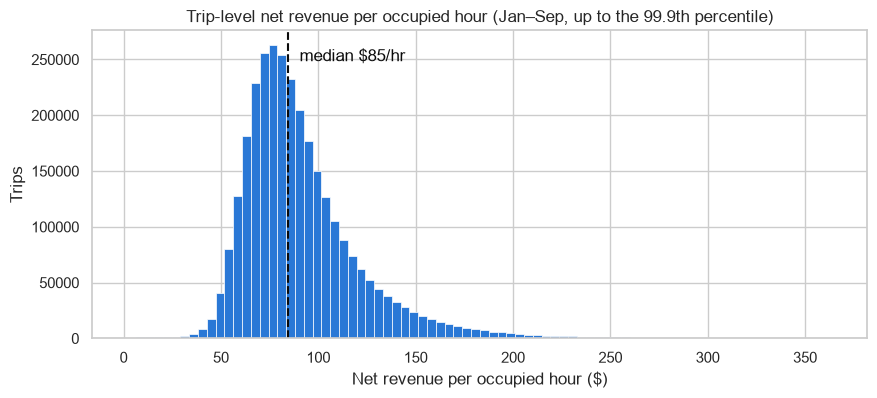

In [194]:
target = eda["net_revenue_per_hour"]
print(target.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).round(2).to_string())

upper = target.quantile(0.999)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(target[target <= upper], bins=80, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(target.median(), color=INK, linewidth=1.5, linestyle="--")
ax.annotate(f"median ${target.median():.0f}/hr", xy=(target.median(), ax.get_ylim()[1] * 0.9),
            xytext=(8, 0), textcoords="offset points", color=INK)
ax.set(title="Trip-level net revenue per occupied hour (Jan–Sep, up to the 99.9th percentile)",
       xlabel="Net revenue per occupied hour ($)", ylabel="Trips")
save_fig(fig, "eda_target_distribution")
plt.show()

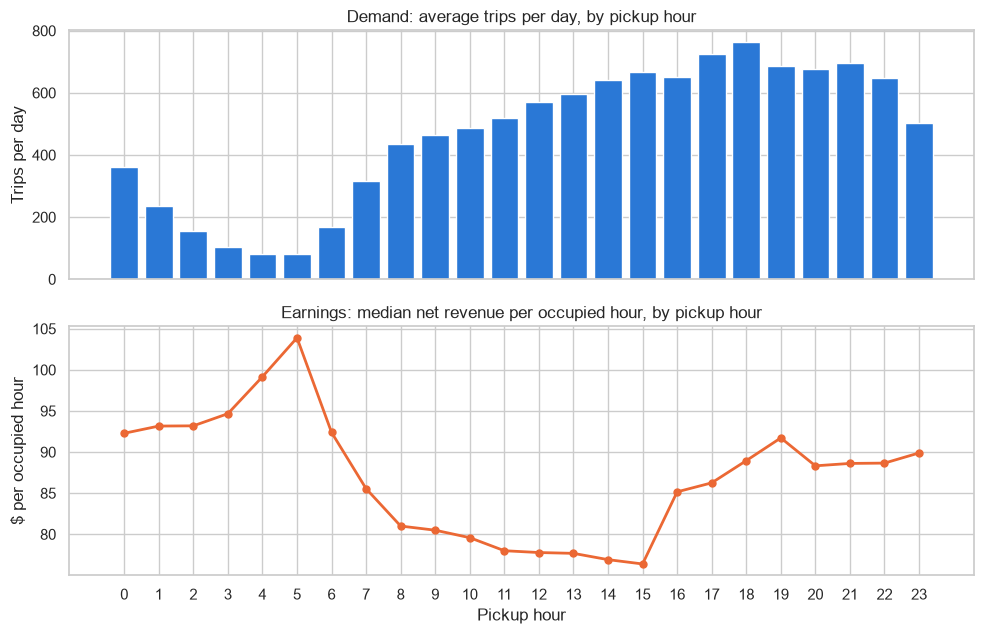

pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
trips_per_day,360.1,235.0,155.7,104.3,79.7,81.5,166.6,316.1,435.8,465.4,485.3,520.0,569.6,596.9,641.5,666.2,652.3,724.8,762.7,686.5,675.8,695.4,647.6,503.2
median_net_per_hour,92.3,93.2,93.2,94.7,99.2,103.9,92.4,85.5,81.0,80.5,79.6,78.0,77.8,77.7,76.9,76.4,85.2,86.3,89.0,91.7,88.3,88.6,88.7,89.9


In [195]:
hourly = eda.groupby("pickup_hour").agg(
    trips=("net_revenue", "size"),
    median_net_per_hour=("net_revenue_per_hour", "median"),
)
hourly["trips_per_day"] = hourly["trips"] / n_days

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.bar(hourly.index, hourly["trips_per_day"], color=BLUE, width=0.8)
ax1.set(title="Demand: average trips per day, by pickup hour", ylabel="Trips per day")

ax2.plot(hourly.index, hourly["median_net_per_hour"], color=ORANGE, linewidth=2, marker="o", markersize=5)
ax2.set(title="Earnings: median net revenue per occupied hour, by pickup hour",
        ylabel="$ per occupied hour", xlabel="Pickup hour")
ax2.set_xticks(range(24))

fig.tight_layout()
save_fig(fig, "eda_demand_vs_earnings_by_hour")
plt.show()
display(hourly[["trips_per_day", "median_net_per_hour"]].round(1).T)

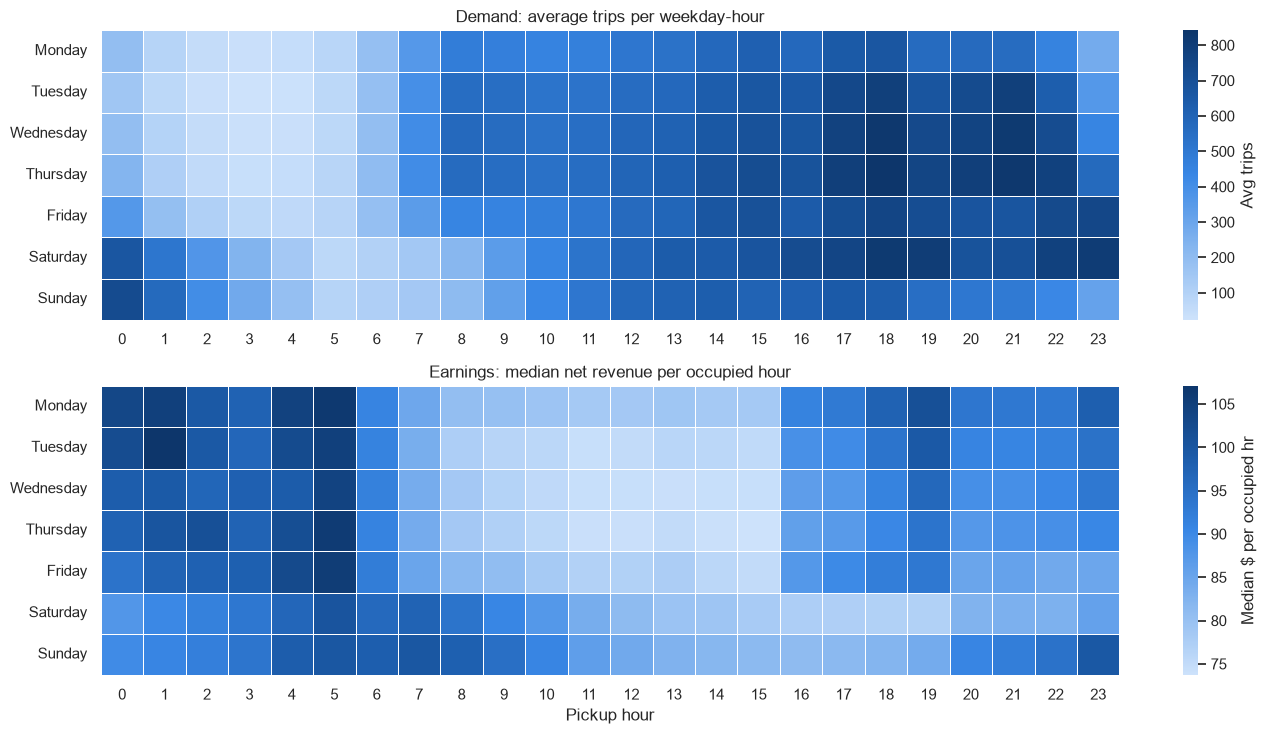

In [196]:
days_per_weekday = eda.groupby("day_of_week", observed=True)["pickup_date"].nunique()

demand_grid = (eda.pivot_table(index="day_of_week", columns="pickup_hour",
                               values="net_revenue", aggfunc="size", observed=True)
                  .div(days_per_weekday, axis=0))          # average trips per weekday-hour
earnings_grid = eda.pivot_table(index="day_of_week", columns="pickup_hour",
                                values="net_revenue_per_hour", aggfunc="median", observed=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5))
sns.heatmap(demand_grid, cmap=SEQ_BLUE, ax=axes[0], linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Avg trips"})
axes[0].set(title="Demand: average trips per weekday-hour", xlabel="", ylabel="")
sns.heatmap(earnings_grid, cmap=SEQ_BLUE, ax=axes[1], linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Median $ per occupied hr"})
axes[1].set(title="Earnings: median net revenue per occupied hour", xlabel="Pickup hour", ylabel="")

fig.tight_layout()
save_fig(fig, "eda_day_hour_heatmaps")
plt.show()

zone demand vs. earnings

Zones with pickups (Jan–Sep): 256
  averaging ≥   1 trips/day: 178
  averaging ≥  10 trips/day: 78
  averaging ≥ 100 trips/day: 38


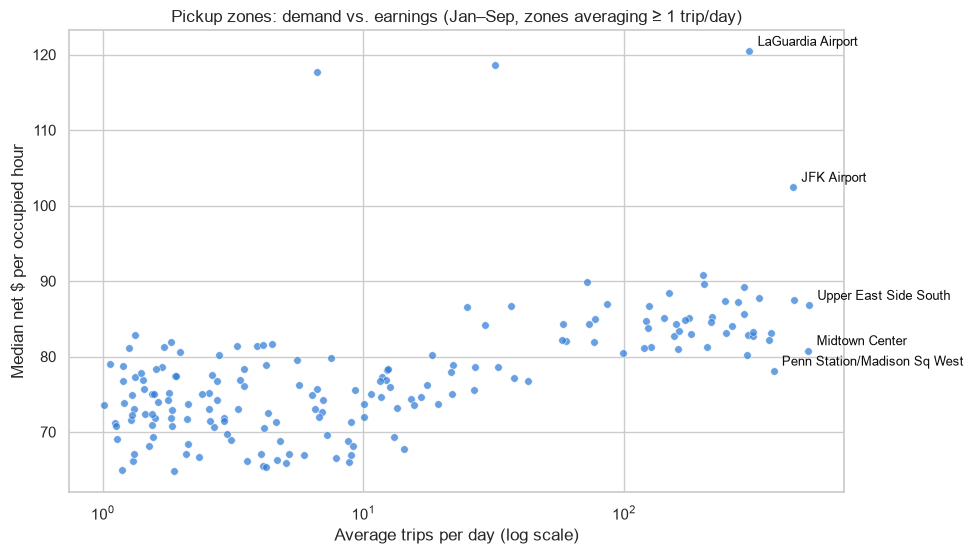

In [197]:
zone_stats = (eda.groupby("PULocationID")
                 .agg(trips=("net_revenue", "size"),
                      median_net_per_hour=("net_revenue_per_hour", "median"),
                      avg_distance_mi=("trip_distance", "mean"))
                 .join(zones.set_index("LocationID")[["Zone", "Borough"]]))
zone_stats["trips_per_day"] = zone_stats["trips"] / n_days

print(f"Zones with pickups (Jan–Sep): {len(zone_stats)}")
for k in [1, 10, 100]:
    print(f"  averaging ≥ {k:>3} trips/day: {(zone_stats['trips_per_day'] >= k).sum()}")

active = zone_stats[zone_stats["trips_per_day"] >= 1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(active["trips_per_day"], active["median_net_per_hour"], s=30, color=BLUE, alpha=0.7,
           edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
for name in ["JFK Airport", "LaGuardia Airport", "Midtown Center", "Upper East Side South",
             "Penn Station/Madison Sq West"]:
    row = active[active["Zone"] == name].iloc[0]
    ax.annotate(name, (row["trips_per_day"], row["median_net_per_hour"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9, color=INK)
ax.set(title="Pickup zones: demand vs. earnings (Jan–Sep, zones averaging ≥ 1 trip/day)",
       xlabel="Average trips per day (log scale)", ylabel="Median net $ per occupied hour")
save_fig(fig, "eda_zone_demand_vs_earnings")
plt.show()

highest- and lowest-earning zones

In [198]:
cols = ["Zone", "Borough", "trips_per_day", "median_net_per_hour", "avg_distance_mi"]
print("Highest median $/hr (zones averaging ≥ 1 trip/day):")
display(active.nlargest(10, "median_net_per_hour")[cols].round(1))
print("Lowest median $/hr:")
display(active.nsmallest(10, "median_net_per_hour")[cols].round(1))

Highest median $/hr (zones averaging ≥ 1 trip/day):


,Zone,Borough,trips_per_day,median_net_per_hour,avg_distance_mi
PULocationID,,,,,
138,LaGuardia Airport,Queens,302.5,120.4,9.5
70,East Elmhurst,Queens,32.1,118.6,9.3
93,Flushing Meadows-Corona Park,Queens,6.6,117.7,9.4
132,JFK Airport,Queens,444.8,102.4,15.6
263,Yorkville West,Manhattan,201.0,90.8,2.4
13,Battery Park City,Manhattan,71.8,89.8,4.3
238,Upper West Side North,Manhattan,202.2,89.6,2.4
239,Upper West Side South,Manhattan,287.8,89.2,2.3
262,Yorkville East,Manhattan,148.4,88.4,2.6


Lowest median $/hr:


,Zone,Borough,trips_per_day,median_net_per_hour,avg_distance_mi
PULocationID,,,,,
26,Borough Park,Brooklyn,1.9,64.8,4.0
22,Bensonhurst West,Brooklyn,1.2,64.9,4.3
91,Flatlands,Brooklyn,4.2,65.4,4.7
71,East Flatbush/Farragut,Brooklyn,4.1,65.6,5.0
72,East Flatbush/Remsen Village,Brooklyn,5.0,65.9,4.6
188,Prospect-Lefferts Gardens,Brooklyn,8.8,66.1,4.9
165,Midwood,Brooklyn,1.3,66.1,4.0
85,Erasmus,Brooklyn,3.6,66.2,5.3
35,Brownsville,Brooklyn,4.6,66.3,4.9


trip speed vs. earnings

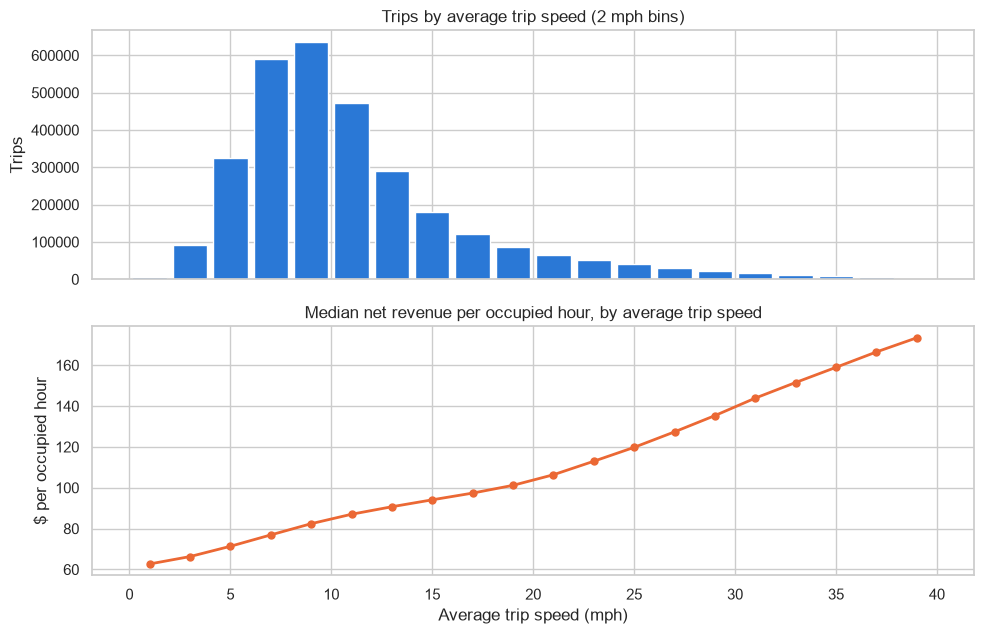

In [199]:
speed_bins = np.arange(0, 42, 2)
by_speed = (eda[eda["speed_mph"] < 40]
              .groupby(pd.cut(eda["speed_mph"], speed_bins, right=False), observed=True)
              .agg(trips=("net_revenue", "size"),
                   median_net_per_hour=("net_revenue_per_hour", "median")))
mid = speed_bins[:-1] + 1  # bin midpoints for plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax1.bar(mid, by_speed["trips"], width=1.7, color=BLUE)
ax1.set(title="Trips by average trip speed (2 mph bins)", ylabel="Trips")
ax2.plot(mid, by_speed["median_net_per_hour"], color=ORANGE, linewidth=2, marker="o", markersize=5)
ax2.set(title="Median net revenue per occupied hour, by average trip speed",
        ylabel="$ per occupied hour", xlabel="Average trip speed (mph)")
fig.tight_layout()
save_fig(fig, "eda_speed_vs_earnings")
plt.show()

weekly trend

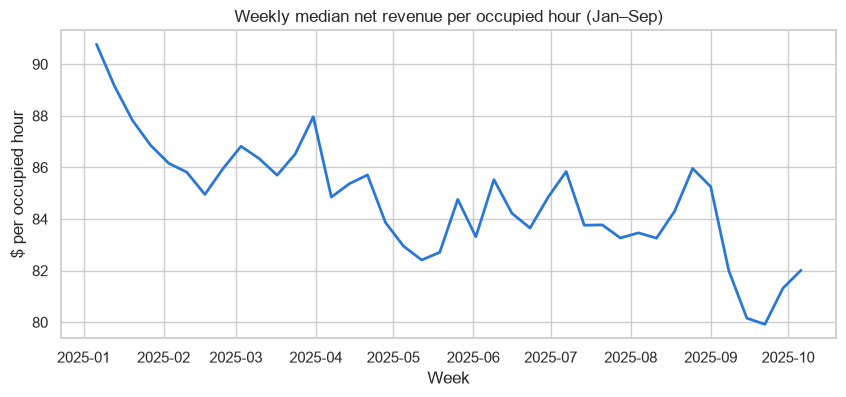

In [200]:
weekly = eda.set_index("pickup_date")["net_revenue_per_hour"].resample("W-MON").median()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly.index, weekly.values, color=BLUE, linewidth=2)
ax.set(title="Weekly median net revenue per occupied hour (Jan–Sep)",
       xlabel="Week", ylabel="$ per occupied hour")
save_fig(fig, "eda_weekly_trend")
plt.show()

### 3.1 EDA findings (Jan–Sep only)

| ID | Finding | Implication |
|---|---|---|
| E1 | The target is right-skewed: median $84.64/hr, 99th percentile $209, max $5,890 | MAE as the primary metric; medians for the baseline; an outlier rule at the zone-hour level (§4) |
| E2 | Earnings and demand move in opposite directions across the day: 5 AM has the highest median $/hr ($103.9) but only ~81 trips/day; midday (11 AM–3 PM) has high demand but the lowest $/hr (~$77); 5–9 PM combines high demand with above-average $/hr | AQ1 cannot rank by $/hr alone; deployment priority must combine predicted $/hr with expected demand (§8.1) |
| E3 | Day matters: weekday pre-dawn hours earn the most per occupied hour, weekend mornings (6–9 AM) are strong, Saturday evenings are busy but earn less | Day × hour interactions; keep `day_of_week` (`is_weekend` is redundant with it) |
| E4 | Demand is concentrated: only 78 of 256 zones average ≥ 10 trips/day | Many zone-hours will have 0–1 trips, making their $/hr noisy; a minimum-trip rule is needed (§4) |
| E5 | Airports lead on both earnings and demand (LaGuardia $120/hr at ~303 trips/day; JFK $102/hr at ~445). The busiest Manhattan zones are mid-range (Midtown Center ~$81, Penn Station ~$78); the lowest earners are low-volume Brooklyn zones (~$65) | Zone identity is a key predictor; the deployment table must show zone names |
| E6 | $/hr rises steadily with a trip's own speed (~$66 at 2–4 mph → ~$173 at 38+ mph), with no visible tipping point | Partly mechanical: a trip's speed is measured during the trip itself, so it cannot be a predictor. AQ3 uses each zone's speed in the **previous hour** (§4) and looks for thresholds there |
| E7 | Average $/hr drifts down over the year (monthly mean $95.87 in January → $88.48 in September) | Later months are harder to predict; expanding-window folds and refitting on all pre-test data address this; test error is expected to exceed early-fold error |

## 4. Aggregation to zone × hour

| ID | Decision | Reason |
|---|---|---|
| M1 | Models cover **deployable slots**: zone × weekday × hour combinations that averaged **≥ 3 trips per hour in Jan–Sep** | A dispatcher knows a slot's history in advance, but not whether the coming hour will get 3+ trips. Choosing slots from history keeps the test honest (filtering on each hour's own trip count would use information from that hour) and removes most single-trip noise (E4) |
| M2 | Extreme targets are capped **in training data only**, at the 99.9th percentile of each fold's training set (applied in §6) | Prevents a few extreme hours from dominating SVR/NN; validation and test are always scored on real values (E1) |

Note: slot eligibility uses Jan–Sep trip counts, which include the validation months. It only uses demand counts, never the target, and the final test (Oct–Nov) is selected purely from pre-test history.

4.1 aggregate trips

In [201]:
abt["pickup_hour_ts"] = abt["tpep_pickup_datetime"].dt.floor("h")

zone_hour = (abt.groupby(["PULocationID", "pickup_hour_ts"])
                .agg(trip_count=("net_revenue", "size"),
                     total_net_revenue=("net_revenue", "sum"),
                     total_net_revenue_ex_tip=("net_revenue_ex_tip", "sum"),
                     total_occupied_min=("duration_min", "sum"),
                     total_distance_mi=("trip_distance", "sum"),
                     avg_fee_impact_pct=("fee_impact_pct", "mean"),
                     avg_congestion_fee_pct=("congestion_fee_pct", "mean"),
                     avg_fare=("fare_amount", "mean"))
                .reset_index())

# Target: built from summed components, never by averaging trip-level $/hr
zone_hour["net_revenue_per_hour"] = zone_hour["total_net_revenue"] / zone_hour["total_occupied_min"] * 60
zone_hour["net_revenue_ex_tip_per_hour"] = zone_hour["total_net_revenue_ex_tip"] / zone_hour["total_occupied_min"] * 60
zone_hour["zone_speed_mph"] = zone_hour["total_distance_mi"] / zone_hour["total_occupied_min"] * 60

print(f"Zone-hours with at least one trip: {len(zone_hour):,}")
zone_hour.head()

Zone-hours with at least one trip: 536,251


,PULocationID,pickup_hour_ts,trip_count,total_net_revenue,total_net_revenue_ex_tip,total_occupied_min,total_distance_mi,avg_fee_impact_pct,avg_congestion_fee_pct,avg_fare,net_revenue_per_hour,net_revenue_ex_tip_per_hour,zone_speed_mph
0,1,2025-01-02 16:00:00,1,104.80,94.8,45.650000,16.19,0.788644,0.000000,92.3,137.743702,124.600219,21.279299
1,1,2025-01-26 23:00:00,1,108.40,87.7,34.650000,17.10,1.408904,0.603816,86.7,187.705628,151.861472,29.610390
2,1,2025-02-14 15:00:00,1,95.20,90.2,62.233333,14.50,1.548536,0.663658,90.2,91.783610,86.963042,13.979646
3,1,2025-02-24 16:00:00,1,110.47,89.2,46.816667,15.68,1.371473,0.587774,86.7,141.577786,114.318263,20.095408
4,1,2025-04-20 22:00:00,1,72.70,60.7,25.300000,16.00,5.190690,3.551524,59.7,172.411067,143.952569,37.944664


4.2 complete zone × hour grid

In [202]:
all_hours = pd.date_range("2025-01-01 00:00", "2025-11-30 23:00", freq="h")
all_zones = np.sort(abt["PULocationID"].unique())

panel = (pd.MultiIndex.from_product([all_zones, all_hours], names=["PULocationID", "pickup_hour_ts"])
           .to_frame(index=False)
           .merge(zone_hour, on=["PULocationID", "pickup_hour_ts"], how="left"))

panel["trip_count"] = panel["trip_count"].fillna(0).astype("int32")   # no record = zero trips
panel["hour"] = panel["pickup_hour_ts"].dt.hour.astype("int8")
panel["day_of_week"] = pd.Categorical(panel["pickup_hour_ts"].dt.day_name(), categories=DAY_ORDER, ordered=True)
panel["month"] = panel["pickup_hour_ts"].dt.month.astype("int8")

print(f"Grid: {len(all_zones)} zones × {len(all_hours):,} hours = {len(panel):,} rows")
print(f"Hours with zero trips: {(panel['trip_count'] == 0).mean():.1%}")

Grid: 258 zones × 8,016 hours = 2,068,128 rows
Hours with zero trips: 74.1%


4.3 deployable slots (M1)

In [203]:
MIN_AVG_TRIPS = 3  # M1

pre_test = panel[panel["pickup_hour_ts"] < TEST_START]
slot_avg_trips = (pre_test.groupby(["PULocationID", "day_of_week", "hour"], observed=True)["trip_count"]
                          .mean()
                          .rename("slot_avg_trips")
                          .reset_index())

panel = panel.merge(slot_avg_trips, on=["PULocationID", "day_of_week", "hour"], how="left")
panel["deployable"] = panel["slot_avg_trips"] >= MIN_AVG_TRIPS

slots = slot_avg_trips[slot_avg_trips["slot_avg_trips"] >= MIN_AVG_TRIPS]
model_rows = panel[panel["deployable"] & (panel["trip_count"] > 0)]

print(f"Deployable slots: {len(slots):,} of {len(slot_avg_trips):,} zone-weekday-hour slots")
print(f"Zones with at least one deployable slot: {slots['PULocationID'].nunique()}")
print(f"Modeling rows (deployable and observed): {len(model_rows):,}")
print(f"  pre-test: {(model_rows['pickup_hour_ts'] < TEST_START).sum():,} | "
      f"test: {(model_rows['pickup_hour_ts'] >= TEST_START).sum():,}")
print(f"Share of all trips covered: {model_rows['trip_count'].sum() / len(abt):.1%}")
print(f"Single-trip rows among modeling rows: {(model_rows['trip_count'] == 1).mean():.1%}")

Deployable slots: 5,674 of 43,344 zone-weekday-hour slots
Zones with at least one deployable slot: 60
Modeling rows (deployable and observed): 268,475
  pre-test: 219,420 | test: 49,055
Share of all trips covered: 88.3%
Single-trip rows among modeling rows: 2.5%


4.4 checks

In [204]:
checks = {
    "Every trip accounted for in the grid":      panel["trip_count"].sum() == len(abt),
    "One row per zone-hour (no duplicates)":     not panel.duplicated(["PULocationID", "pickup_hour_ts"]).any(),
    "Grid size = zones × hours":                 len(panel) == len(all_zones) * len(all_hours),
    "Target present exactly when trips > 0":     (panel["net_revenue_per_hour"].notna() == (panel["trip_count"] > 0)).all(),
    "Target positive where present":             (panel["net_revenue_per_hour"].dropna() > 0).all(),
}
results = pd.Series(checks, name="passed")
display(results.to_frame())
assert results.all(), f"Failed: {list(results[~results].index)}"

print("Deployable zones by borough:")
dz = zones.set_index("LocationID").loc[slots["PULocationID"].unique()]
print(dz["Borough"].value_counts().to_string())

,passed
Every trip accounted for in the grid,True
One row per zone-hour (no duplicates),True
Grid size = zones × hours,True
Target present exactly when trips > 0,True
Target positive where present,True


Deployable zones by borough:
Borough
Manhattan    51
Brooklyn      5
Queens        4


## 5. Features

Every feature is known **before** the hour being predicted (leakage rule).

| Feature | Meaning | Why |
|---|---|---|
| `PULocationID` | Pickup zone | Zone is a key driver of earnings (E5) |
| `hour`, `day_of_week` | Time slot | Day × hour pattern (E2, E3); `is_weekend` dropped as redundant |
| `is_holiday` | US federal holiday | Holidays shift demand; the test period contains three (Oct 13, Nov 11, Nov 27) |
| `trips_lag1h`, `trips_prev3h` | Trips in the zone in the previous hour / previous 3 hours | Recent demand |
| `trips_lag24h`, `trips_lag168h` | Trips at the same hour yesterday / one week ago | Daily and weekly demand pattern |
| `speed_prev1h`, `speed_prev3h`, `speed_lag24h` | Zone traffic speed (total miles ÷ total minutes) in the previous hour / previous 3 hours / same hour yesterday | Recent congestion; the basis for AQ3 thresholds (E6) |
| `fee_pct_lag24h` | Average fee share of gross, same hour yesterday | Typical fee exposure of the slot (AQ2) |
| `nrph_lag24h`, `nrph_lag168h` | Net $/hr at the same hour yesterday / one week ago | Recent earnings level of the slot |

`month` is **not** used: the test months (Oct–Nov) never appear in training, so a model could not learn anything valid about them. The first 7 days of January are dropped because week-ago features don't exist yet.

In [205]:
from pandas.tseries.holiday import USFederalHolidayCalendar

holidays = USFederalHolidayCalendar().holidays(start="2025-01-01", end="2025-11-30")
panel["is_holiday"] = panel["pickup_hour_ts"].dt.normalize().isin(holidays).astype("int8")

print("Holidays in the study period:")
print([d.strftime("%b %d (%a)") for d in holidays])

Holidays in the study period:
['Jan 01 (Wed)', 'Jan 20 (Mon)', 'Feb 17 (Mon)', 'May 26 (Mon)', 'Jun 19 (Thu)', 'Jul 04 (Fri)', 'Sep 01 (Mon)', 'Oct 13 (Mon)', 'Nov 11 (Tue)', 'Nov 27 (Thu)']


lag and rolling features

In [206]:
panel = panel.sort_values(["PULocationID", "pickup_hour_ts"]).reset_index(drop=True)
by_zone = panel.groupby("PULocationID")

def lag(col, hours):
    """Value of `col` in the same zone, `hours` hours earlier."""
    return by_zone[col].shift(hours)

# Demand
panel["trips_lag1h"] = lag("trip_count", 1)
panel["trips_prev3h"] = lag("trip_count", 1) + lag("trip_count", 2) + lag("trip_count", 3)
panel["trips_lag24h"] = lag("trip_count", 24)
panel["trips_lag168h"] = lag("trip_count", 168)

# Traffic speed (blank when the zone had no trips in that window)
dist_3h = sum(lag("total_distance_mi", k).fillna(0) for k in (1, 2, 3))
mins_3h = sum(lag("total_occupied_min", k).fillna(0) for k in (1, 2, 3))
panel["speed_prev1h"] = lag("zone_speed_mph", 1)
panel["speed_prev3h"] = (dist_3h / mins_3h * 60).where(mins_3h > 0)
panel["speed_lag24h"] = lag("zone_speed_mph", 24)

# Fee exposure and recent earnings
panel["fee_pct_lag24h"] = lag("avg_fee_impact_pct", 24)
panel["nrph_lag24h"] = lag("net_revenue_per_hour", 24)
panel["nrph_lag168h"] = lag("net_revenue_per_hour", 168)

the modeling table

In [207]:
FEATURES = ["PULocationID", "hour", "day_of_week", "is_holiday",
            "trips_lag1h", "trips_prev3h", "trips_lag24h", "trips_lag168h",
            "speed_prev1h", "speed_prev3h", "speed_lag24h",
            "fee_pct_lag24h", "nrph_lag24h", "nrph_lag168h"]
TARGET = "net_revenue_per_hour"
FEATURE_START = all_hours[0] + pd.Timedelta(hours=168)   # first full week of lags

model_df = panel[panel["deployable"]
                 & (panel["trip_count"] > 0)
                 & (panel["pickup_hour_ts"] >= FEATURE_START)].copy()
model_df["is_test"] = model_df["pickup_hour_ts"] >= TEST_START

print(f"Modeling rows: {len(model_df):,} "
      f"(pre-test {(~model_df['is_test']).sum():,} | test {model_df['is_test'].sum():,})")
print(f"Period: {model_df['pickup_hour_ts'].min()} → {model_df['pickup_hour_ts'].max()}")
print("\nMissing values per feature (share of rows):")
print(model_df[FEATURES].isna().mean().round(3).to_string())

Modeling rows: 263,047 (pre-test 213,992 | test 49,055)
Period: 2025-01-08 00:00:00 → 2025-11-30 23:00:00

Missing values per feature (share of rows):
PULocationID      0.000
hour              0.000
day_of_week       0.000
is_holiday        0.000
trips_lag1h       0.000
trips_prev3h      0.000
trips_lag24h      0.000
trips_lag168h     0.000
speed_prev1h      0.015
speed_prev3h      0.003
speed_lag24h      0.014
fee_pct_lag24h    0.014
nrph_lag24h       0.014
nrph_lag168h      0.008


leakage and alignment checks

In [208]:
# 1) Each zone's hours are continuous, so shift(k) really means k hours earlier
gaps_ok = by_zone["pickup_hour_ts"].diff().dropna().eq(pd.Timedelta(hours=1)).all()

# 2) Spot-check: trips_lag24h equals the trip count 24 hours earlier, looked up independently
sample = model_df.sample(2_000, random_state=RANDOM_STATE)[["PULocationID", "pickup_hour_ts", "trips_lag24h"]]
lookup = panel.set_index(["PULocationID", "pickup_hour_ts"])["trip_count"]
earlier = lookup.reindex(list(zip(sample["PULocationID"], sample["pickup_hour_ts"] - pd.Timedelta(hours=24)))).to_numpy()
lag_ok = np.array_equal(sample["trips_lag24h"].to_numpy(), earlier)

# 3) No numeric feature is a near-copy of the target
num_feats = [f for f in FEATURES if f not in ("PULocationID", "day_of_week")]
max_corr = model_df[num_feats].corrwith(model_df[TARGET]).abs().max()

checks = {
    "Hourly grid continuous within every zone": gaps_ok,
    "Lag spot-check matches independent lookup": lag_ok,
    "No feature is a near-copy of the target (|r| < 0.95)": max_corr < 0.95,
    "No test rows before TEST_START": (model_df.loc[model_df["is_test"], "pickup_hour_ts"] >= TEST_START).all(),
}
results = pd.Series(checks, name="passed")
display(results.to_frame())
assert results.all(), f"Failed: {list(results[~results].index)}"
print(f"Highest |correlation| of any feature with the target: {max_corr:.2f}")

,passed
Hourly grid continuous within every zone,True
Lag spot-check matches independent lookup,True
No feature is a near-copy of the target (|r| < 0.95),True
No test rows before TEST_START,True


Highest |correlation| of any feature with the target: 0.48


## 6. Validation design and preprocessing

**Expanding-window folds.** Each fold trains on all pre-test months before its validation month:

| Fold | Train | Validate |
|---|---|---|
| 1 | Jan 8 – May | June |
| 2 | Jan 8 – Jun | July |
| 3 | Jan 8 – Jul | August |
| 4 | Jan 8 – Aug | September |
| Final | Jan 8 – Sep | **Test: Oct – Nov** (used once) |

**Preprocessing**, always fit on the training rows of a fold only:
- **XGBoost:** zone and day as native categories; blanks handled natively; no scaling.
- **SVR / neural network:** blanks filled with the training median, numeric features standardized, zone / day / hour one-hot encoded; the target is also standardized during fitting (§7).
- **Target cap (M2):** training targets capped at the training set's 99.9th percentile; validation and test targets are never changed.

build the folds

In [209]:
pre_test = model_df[~model_df["is_test"]]
test_df = model_df[model_df["is_test"]]

folds = []
for m in VALIDATION_MONTHS:
    folds.append({
        "fold": len(folds) + 1,
        "train_idx": pre_test.index[pre_test["month"] < m],
        "val_idx": pre_test.index[pre_test["month"] == m],
        "val_month": pd.Timestamp(2025, m, 1).strftime("%B"),
    })

fold_table = pd.DataFrame([{
    "fold": f["fold"],
    "train_period": f"{model_df.loc[f['train_idx'], 'pickup_hour_ts'].min():%b %d} – "
                    f"{model_df.loc[f['train_idx'], 'pickup_hour_ts'].max():%b %d}",
    "train_rows": len(f["train_idx"]),
    "validate": f["val_month"],
    "val_rows": len(f["val_idx"]),
} for f in folds])
display(fold_table)
print(f"Final refit: {len(pre_test):,} pre-test rows → test: {len(test_df):,} rows (Oct–Nov)")

# Checks: validation always comes after training; test after everything
for f in folds:
    assert model_df.loc[f["train_idx"], "pickup_hour_ts"].max() < model_df.loc[f["val_idx"], "pickup_hour_ts"].min()
    assert len(set(f["train_idx"]) & set(f["val_idx"])) == 0
assert pre_test["pickup_hour_ts"].max() < test_df["pickup_hour_ts"].min()
print("Folds are strictly chronological with no overlap ✓")

,fold,train_period,train_rows,validate,val_rows
0,1,Jan 08 – May 31,115898,June,24168
1,2,Jan 08 – Jun 30,140066,July,24896
2,3,Jan 08 – Jul 31,164962,August,24938
3,4,Jan 08 – Aug 31,189900,September,24092


Final refit: 213,992 pre-test rows → test: 49,055 rows (Oct–Nov)
Folds are strictly chronological with no overlap ✓


preprocessing for each model type

In [210]:
CAT_FEATURES = ["PULocationID", "day_of_week"]
NUM_FEATURES = [f for f in FEATURES if f not in CAT_FEATURES]

# --- XGBoost: native categories (the zone list is fixed: the 60 deployable zones) ---
ZONE_DTYPE = pd.CategoricalDtype(categories=np.sort(model_df["PULocationID"].unique()))

def to_xgb(X):
    X = X.copy()
    X["PULocationID"] = X["PULocationID"].astype(ZONE_DTYPE)
    return X

# --- SVR / neural network: impute + scale numerics, one-hot categories and hour ---
def make_preprocessor():
    """A fresh, unfitted preprocessor; it gets fit inside each fold's training data only."""
    numeric = [f for f in NUM_FEATURES if f != "hour"]
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["PULocationID", "day_of_week", "hour"]),
    ])

# --- Target cap (M2), training rows only ---
def cap_train_target(y):
    return y.clip(upper=y.quantile(0.999))

# Quick look at what each model type receives (fold 1 training data)
X1 = model_df.loc[folds[0]["train_idx"], FEATURES]
pre1 = make_preprocessor().fit(X1)
print(f"XGBoost input: {to_xgb(X1).shape[1]} columns (zone and day as categories)")
print(f"SVR / NN input: {pre1.transform(X1).shape[1]} columns after one-hot encoding")
y1 = model_df.loc[folds[0]["train_idx"], TARGET]
print(f"Fold 1 training target cap: ${y1.quantile(0.999):.2f}/hr "
      f"({(y1 > y1.quantile(0.999)).sum()} rows capped)")

XGBoost input: 14 columns (zone and day as categories)
SVR / NN input: 102 columns after one-hot encoding
Fold 1 training target cap: $194.42/hr (116 rows capped)


## 6.1 Evaluation toolkit

Defined once, before any model is trained, and applied identically to every model.

| Metric | Question it answers | Better |
|---|---|---|
| **MAE** (primary) | How many $/hr off is a typical prediction? | Lower |
| RMSE | Are there large misses? (penalizes big errors more) | Lower |
| R² | How much of the variation is explained? | Higher |
| Spearman (overall) | Does the model order zone-hours correctly across the whole period? | Higher |
| **Spearman within hour** | At a given hour, does it order the zones correctly? (the dispatcher's real question) | Higher |
| **Precision@10** | At a given hour, how many of the model's top-10 zones are truly in the top 10? | Higher |
| MAE gain vs. baseline (95% CI) | Is the improvement over the naive baseline real, or could it be luck? Resamples whole days | Interval above 0 |
| Segment MAE | Where does the model fail? (time of day, trip volume, airport vs. non-airport) | — |

Ranking metrics use only hours with at least 20 observed zones, so a top-10 is meaningful.

the metric functions

In [211]:
TOP_K = 10
MIN_ZONES_FOR_RANKING = 2 * TOP_K
N_BOOT = 1_000
AIRPORT_ZONES = zones.loc[zones["Zone"].str.contains("Airport"), "LocationID"].tolist()

def ranking_metrics(ts, y, p, k=TOP_K, min_zones=MIN_ZONES_FOR_RANKING):
    """Within-hour Spearman and Precision@k, averaged over hours with enough zones."""
    d = pd.DataFrame({"ts": ts, "y": y, "p": p})
    d = d[d.groupby("ts")["y"].transform("size") >= min_zones]
    grouped = d.groupby("ts")
    rho = grouped.apply(lambda g: g["y"].corr(g["p"], method="spearman"), include_groups=False).mean()
    prec = grouped.apply(lambda g: len(set(g.nlargest(k, "y").index) & set(g.nlargest(k, "p").index)) / k,
                         include_groups=False).mean()
    return rho, prec, d["ts"].nunique()

def evaluate(frame, pred, model_name, split_name):
    """All point and ranking metrics for one set of predictions."""
    y = frame[TARGET].to_numpy()
    p = np.asarray(pred, dtype=float)
    rho_hour, p_at_k, n_hours = ranking_metrics(frame["pickup_hour_ts"].to_numpy(), y, p)
    return {
        "model": model_name, "split": split_name, "rows": len(y),
        "MAE": mean_absolute_error(y, p),
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "R2": r2_score(y, p),
        "Spearman": pd.Series(y).corr(pd.Series(p), method="spearman"),
        "Spearman_within_hour": rho_hour,
        f"Precision@{TOP_K}": p_at_k,
        "ranked_hours": n_hours,
    }

def bootstrap_mae_gain(frame, pred_model, pred_base, n_boot=N_BOOT, seed=RANDOM_STATE):
    """% MAE reduction vs. the baseline, with a 95% CI from resampling whole days."""
    y = frame[TARGET].to_numpy()
    base_err = np.abs(y - pred_base)
    gain = base_err - np.abs(y - pred_model)          # > 0 where the model is closer
    daily = (pd.DataFrame({"day": frame["pickup_hour_ts"].dt.normalize().to_numpy(),
                           "gain": gain, "base_err": base_err})
               .groupby("day")[["gain", "base_err"]].sum())
    rng = np.random.default_rng(seed)
    pick = rng.integers(0, len(daily), size=(n_boot, len(daily)))
    pct = daily["gain"].to_numpy()[pick].sum(1) / daily["base_err"].to_numpy()[pick].sum(1) * 100
    point = daily["gain"].sum() / daily["base_err"].sum() * 100
    low, high = np.percentile(pct, [2.5, 97.5])
    return point, low, high

def segment_mae(frame, pred):
    """MAE broken down by time of day, trip volume and airport vs. non-airport."""
    d = frame.assign(abs_err=np.abs(frame[TARGET].to_numpy() - np.asarray(pred, dtype=float)))
    d["time_band"] = pd.cut(d["hour"], [-1, 5, 9, 15, 20, 23],
                            labels=["Overnight 0–5", "Morning 6–9", "Midday 10–15", "Evening 16–20", "Late 21–23"])
    d["trip_volume"] = pd.cut(d["trip_count"], [0, 2, 9, np.inf], labels=["1–2 trips", "3–9 trips", "10+ trips"])
    d["zone_type"] = np.where(d["PULocationID"].isin(AIRPORT_ZONES), "Airport", "Non-airport")
    parts = [d.groupby(seg, observed=True)["abs_err"].agg(rows="size", MAE="mean")
              .reset_index().rename(columns={seg: "group"}).assign(segment=seg, group=lambda t: t["group"].astype(str))
             for seg in ["time_band", "trip_volume", "zone_type"]]
    return pd.concat(parts, ignore_index=True)[["segment", "group", "rows", "MAE"]]

results = []   # every evaluate() result is appended here; §8 builds the comparison from it

test the toolkit on known answers

In [212]:
val1 = model_df.loc[folds[0]["val_idx"]]
y_val1 = val1[TARGET].to_numpy()
rng = np.random.default_rng(RANDOM_STATE)

sanity = pd.DataFrame([
    evaluate(val1, y_val1, "Perfect (prediction = truth)", "Fold 1 val"),
    evaluate(val1, rng.permutation(y_val1), "Random (shuffled truth)", "Fold 1 val"),
])
display(sanity.round(3))

gain_pt, gain_lo, gain_hi = bootstrap_mae_gain(val1, y_val1, rng.permutation(y_val1))
print(f"Perfect vs. random: {gain_pt:.1f}% MAE reduction (95% CI {gain_lo:.1f}% to {gain_hi:.1f}%)")
display(segment_mae(val1, rng.permutation(y_val1)))

,model,split,rows,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10,ranked_hours
0,Perfect (prediction = truth),Fold 1 val,24168,0.000,0.000,1.000,1.0,1.000,1.000,553
1,Random (shuffled truth),Fold 1 val,24168,16.497,22.799,-1.003,-0.0,-0.001,0.247,553


Perfect vs. random: 100.0% MAE reduction (95% CI 100.0% to 100.0%)


,segment,group,rows,MAE
0,time_band,Overnight 0–5,2087,20.520879
1,time_band,Morning 6–9,3631,17.886371
2,time_band,Midday 10–15,7837,15.559625
3,time_band,Evening 16–20,6920,15.618357
4,time_band,Late 21–23,3693,15.641750
5,trip_volume,1–2 trips,1144,23.300339
6,trip_volume,3–9 trips,9884,17.180641
7,trip_volume,10+ trips,13140,15.151312
8,zone_type,Airport,1183,29.682240
9,zone_type,Non-airport,22985,15.681670


## 7. Models

Every model goes through the same procedure:

1. **Cross-validate:** for each fold, fit on the fold's training rows (training targets capped, M2), predict the validation month, evaluate.
2. **Tune:** where a model has settings to choose, pick the setting with the lowest **mean validation MAE across the 4 folds**.
3. **Refit and test once:** refit the chosen setting on all pre-test data (Jan 8 – Sep 30) and evaluate on the test period (Oct – Nov).

### 7.0 Naive baseline: historical median

For each zone × day × hour slot, predict the median net $/hr seen in the training data. If a slot has no training history, fall back to the zone × hour median, then the zone median, then the overall median. It does no learning, so it is the reference every model must beat.

the shared procedure

In [213]:
test_preds = {}   # model name → test-period predictions (used for CIs and segments in §8)
cv_tables = {}    # model name → per-fold validation results

def with_capped_target(train):
    """M2: cap the training target only; validation and test targets are never changed."""
    return train.assign(**{TARGET: cap_train_target(train[TARGET])})

def cross_validate(fit_predict, model_name):
    """Run fit_predict on every fold; return the per-fold validation metrics."""
    rows = []
    for f in folds:
        train = with_capped_target(model_df.loc[f["train_idx"]])
        val = model_df.loc[f["val_idx"]]
        rows.append(evaluate(val, fit_predict(train, val), model_name,
                             f"Fold {f['fold']} ({f['val_month']})"))
    return pd.DataFrame(rows)

def final_test(fit_predict, model_name):
    """Refit on all pre-test data, predict the test period once, and record the result."""
    pred = fit_predict(with_capped_target(pre_test), test_df)
    test_preds[model_name] = pred
    result = evaluate(test_df, pred, model_name, "Test (Oct–Nov)")
    results.append(result)
    return result

def show_cv(table):
    """Per-fold results plus the mean across folds."""
    metrics = ["MAE", "RMSE", "R2", "Spearman", "Spearman_within_hour", f"Precision@{TOP_K}"]
    summary = table[["split"] + metrics].copy()
    summary.loc[len(summary)] = ["Mean of 4 folds"] + table[metrics].mean().tolist()
    display(summary.round(3))

the baseline

In [214]:
def baseline_fit_predict(train, other):
    pred = pd.Series(np.nan, index=other.index)
    for keys in (["PULocationID", "day_of_week", "hour"], ["PULocationID", "hour"], ["PULocationID"]):
        medians = train.groupby(keys, observed=True)[TARGET].median().rename("median")
        pred = pred.fillna(other[keys].join(medians, on=keys)["median"])
    return pred.fillna(train[TARGET].median()).to_numpy()

name = "Naive baseline"
cv_tables[name] = cross_validate(baseline_fit_predict, name)
show_cv(cv_tables[name])

test_result = final_test(baseline_fit_predict, name)
display(pd.DataFrame([test_result]).round(3))

,split,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10
0,Fold 1 (June),8.207,12.067,0.439,0.658,0.371,0.449
1,Fold 2 (July),8.440,13.052,0.418,0.633,0.374,0.468
2,Fold 3 (August),9.099,14.760,0.365,0.610,0.387,0.471
3,Fold 4 (September),8.985,14.247,0.345,0.655,0.388,0.475
4,Mean of 4 folds,8.683,13.532,0.392,0.639,0.380,0.466


,model,split,rows,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10,ranked_hours
0,Naive baseline,Test (Oct–Nov),49055,9.407,13.886,0.398,0.628,0.4,0.468,1121


### 7.1 XGBoost (initial champion candidate)

Gradient-boosted decision trees (Chen & Guestrin, 2016) using native categorical support for zone and day. Ten random configurations are each evaluated on all four folds; the configuration with the lowest mean validation MAE is refit on all pre-test data and tested once.

- The number of trees is a tuned setting. **No early stopping on validation data** (in FA2, using the validation set both to stop training and to score the model made the validation score optimistic).
- The loss function (absolute vs. squared error) is part of the search, so XGBoost has no built-in advantage on MAE over models that can only use squared-type losses.

tuning

In [215]:
def make_xgb_fit_predict(params):
    def fit_predict(train, other):
        model = xgb.XGBRegressor(tree_method="hist", enable_categorical=True,
                                 random_state=RANDOM_STATE, n_jobs=-1, **params)
        model.fit(to_xgb(train[FEATURES]), train[TARGET])
        fit_predict.model = model            # keep the last fitted model (used for SHAP in §9)
        return model.predict(to_xgb(other[FEATURES]))
    return fit_predict

xgb_space = {
    "objective": ["reg:absoluteerror", "reg:squarederror"],
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
xgb_configs = list(ParameterSampler(xgb_space, n_iter=10, random_state=RANDOM_STATE))

xgb_tuning, xgb_cv_by_config = [], []
start = time.perf_counter()
for i, params in enumerate(xgb_configs, 1):
    t0 = time.perf_counter()
    cv = cross_validate(make_xgb_fit_predict(params), "XGBoost")
    xgb_cv_by_config.append(cv)
    xgb_tuning.append({"config": i, **params,
                       "mean_val_MAE": cv["MAE"].mean(), "std_val_MAE": cv["MAE"].std(),
                       "mean_P@10": cv[f"Precision@{TOP_K}"].mean(),
                       "seconds": round(time.perf_counter() - t0)})
    print(f"Config {i:>2}/10 | mean val MAE ${cv['MAE'].mean():.3f} | {xgb_tuning[-1]['seconds']}s")

xgb_tuning = pd.DataFrame(xgb_tuning).sort_values("mean_val_MAE").reset_index(drop=True)
xgb_tuning.to_csv(TABLE_DIR / "xgb_tuning.csv", index=False)
print(f"\nTuning time: {(time.perf_counter() - start) / 60:.1f} min")
display(xgb_tuning.round(3))

Config  1/10 | mean val MAE $8.328 | 9s
Config  2/10 | mean val MAE $8.554 | 5s
Config  3/10 | mean val MAE $8.299 | 12s
Config  4/10 | mean val MAE $8.502 | 11s
Config  5/10 | mean val MAE $8.295 | 7s
Config  6/10 | mean val MAE $8.518 | 9s
Config  7/10 | mean val MAE $8.793 | 17s
Config  8/10 | mean val MAE $8.531 | 5s
Config  9/10 | mean val MAE $8.622 | 8s
Config 10/10 | mean val MAE $8.297 | 11s

Tuning time: 1.6 min


,config,subsample,objective,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,mean_val_MAE,std_val_MAE,mean_P@10,seconds
0,5,0.8,reg:absoluteerror,300,5,6,0.10,1.0,8.295,0.514,0.472,7
1,10,0.8,reg:absoluteerror,600,1,4,0.10,0.8,8.297,0.513,0.472,11
2,3,0.8,reg:absoluteerror,600,5,6,0.10,0.8,8.299,0.511,0.470,12
3,1,0.8,reg:absoluteerror,300,10,8,0.10,1.0,8.328,0.513,0.469,9
4,4,0.8,reg:squarederror,600,1,6,0.03,0.8,8.502,0.514,0.471,11
5,6,1.0,reg:squarederror,300,5,8,0.03,1.0,8.518,0.503,0.469,9
6,8,0.8,reg:squarederror,300,5,4,0.10,0.8,8.531,0.508,0.468,5
7,2,1.0,reg:squarederror,300,1,4,0.05,0.8,8.554,0.512,0.468,5
8,9,1.0,reg:squarederror,300,1,8,0.10,0.8,8.622,0.501,0.464,8
9,7,0.8,reg:squarederror,600,1,8,0.10,1.0,8.793,0.491,0.455,17


best configuration, CV detail and the test

In [216]:
best_i = int(xgb_tuning.loc[0, "config"]) - 1
xgb_best_params = xgb_configs[best_i]
print("Selected configuration:", xgb_best_params)

name = "XGBoost"
cv_tables[name] = xgb_cv_by_config[best_i]
show_cv(cv_tables[name])

xgb_final = make_xgb_fit_predict(xgb_best_params)
test_result = final_test(xgb_final, name)
display(pd.DataFrame([r for r in results if r["split"].startswith("Test")]).round(3))

Selected configuration: {'subsample': 0.8, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


,split,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10
0,Fold 1 (June),7.797,11.637,0.478,0.681,0.396,0.461
1,Fold 2 (July),8.205,12.670,0.451,0.657,0.403,0.484
2,Fold 3 (August),9.015,14.631,0.376,0.619,0.403,0.471
3,Fold 4 (September),8.165,13.549,0.408,0.686,0.398,0.470
4,Mean of 4 folds,8.295,13.122,0.428,0.661,0.400,0.472


,model,split,rows,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10,ranked_hours
0,Naive baseline,Test (Oct–Nov),49055,9.407,13.886,0.398,0.628,0.400,0.468,1121
1,XGBoost,Test (Oct–Nov),49055,8.730,13.373,0.442,0.650,0.399,0.478,1121


### 7.2 Support Vector Regression (Challenger 1)

RBF-kernel SVR (Wu et al., 2003, as benchmarked in Kankanamge et al., 2019). An exact kernel SVR scales between O(n²) and O(n³) with the number of rows, which forced FA2 to train it on a 25,000-row subsample (47 minutes). Here the RBF kernel is approximated with the **Nyström method** (Williams & Seeger, 2001), and a linear SVR with the ε-insensitive loss is fit on the approximated features. This keeps the RBF-kernel SVR formulation while training on **all** training rows, the same data every other model receives.

Preprocessing (median imputation, standardization, one-hot encoding) and **target standardization** are fit inside each fold's training data only.

a reusable tuning function

In [217]:
def run_tuning(make_fit_predict, configs, model_name, table_name):
    """Cross-validate every configuration; return the ranked table and per-config CV results."""
    rows, cv_by_config = [], []
    start = time.perf_counter()
    for i, params in enumerate(configs, 1):
        t0 = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            cv = cross_validate(make_fit_predict(params), model_name)
        not_converged = sum(issubclass(w.category, ConvergenceWarning) for w in caught)
        cv_by_config.append(cv)
        rows.append({"config": i, **params,
                     "mean_val_MAE": cv["MAE"].mean(), "std_val_MAE": cv["MAE"].std(),
                     "mean_P@10": cv[f"Precision@{TOP_K}"].mean(),
                     "fits_not_converged": not_converged,
                     "seconds": round(time.perf_counter() - t0)})
        print(f"Config {i:>2}/{len(configs)} | mean val MAE ${cv['MAE'].mean():.3f} | "
              f"{rows[-1]['seconds']}s | not converged: {not_converged}/4")
    table = pd.DataFrame(rows).sort_values("mean_val_MAE").reset_index(drop=True)
    table.to_csv(TABLE_DIR / table_name, index=False)
    print(f"\nTuning time: {(time.perf_counter() - start) / 60:.1f} min")
    return table, cv_by_config

SVR tuning and test

In [218]:
def make_svr_fit_predict(params):
    def fit_predict(train, other):
        model = TransformedTargetRegressor(
            regressor=Pipeline([
                ("prep", make_preprocessor()),
                ("rbf", Nystroem(kernel="rbf", gamma=params["gamma"],
                                 n_components=params["n_components"], random_state=RANDOM_STATE)),
                ("svr", LinearSVR(C=params["C"], epsilon=params["epsilon"], loss="epsilon_insensitive",
                                  dual=True, max_iter=5_000, random_state=RANDOM_STATE)),
            ]),
            transformer=StandardScaler(),     # target standardized during fitting
        )
        model.fit(train[FEATURES], train[TARGET])
        fit_predict.model = model
        return model.predict(other[FEATURES])
    return fit_predict

svr_space = {"n_components": [300, 600], "gamma": [0.005, 0.01, 0.02],
             "C": [0.01, 0.1, 1.0], "epsilon": [0.0, 0.1]}
svr_configs = list(ParameterSampler(svr_space, n_iter=6, random_state=RANDOM_STATE))

svr_tuning, svr_cv_by_config = run_tuning(make_svr_fit_predict, svr_configs, "SVR", "svr_tuning.csv")
display(svr_tuning.round(3))

best_i = int(svr_tuning.loc[0, "config"]) - 1
print("Selected configuration:", svr_configs[best_i])
name = "SVR"
cv_tables[name] = svr_cv_by_config[best_i]
show_cv(cv_tables[name])

test_result = final_test(make_svr_fit_predict(svr_configs[best_i]), name)
display(pd.DataFrame([r for r in results if r["split"].startswith("Test")]).round(3))

Config  1/6 | mean val MAE $8.499 | 35s | not converged: 0/4
Config  2/6 | mean val MAE $8.711 | 14s | not converged: 0/4
Config  3/6 | mean val MAE $8.601 | 20s | not converged: 0/4
Config  4/6 | mean val MAE $8.618 | 19s | not converged: 0/4
Config  5/6 | mean val MAE $8.683 | 7s | not converged: 0/4
Config  6/6 | mean val MAE $8.536 | 34s | not converged: 0/4

Tuning time: 2.2 min


,config,n_components,gamma,epsilon,C,mean_val_MAE,std_val_MAE,mean_P@10,fits_not_converged,seconds
0,1,600,0.020,0.1,1.0,8.499,0.554,0.459,0,35
1,6,600,0.005,0.1,1.0,8.536,0.556,0.461,0,34
2,3,300,0.010,0.0,1.0,8.601,0.558,0.457,0,20
3,4,300,0.005,0.1,1.0,8.618,0.545,0.457,0,19
4,5,300,0.020,0.0,0.1,8.683,0.526,0.449,0,7
5,2,600,0.005,0.0,0.1,8.711,0.538,0.448,0,14


Selected configuration: {'n_components': 600, 'gamma': 0.02, 'epsilon': 0.1, 'C': 1.0}


,split,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10
0,Fold 1 (June),8.013,11.939,0.451,0.660,0.372,0.449
1,Fold 2 (July),8.457,12.995,0.423,0.633,0.374,0.471
2,Fold 3 (August),9.284,14.974,0.346,0.593,0.377,0.458
3,Fold 4 (September),8.243,13.732,0.392,0.664,0.363,0.457
4,Mean of 4 folds,8.499,13.410,0.403,0.638,0.371,0.459


,model,split,rows,MAE,RMSE,R2,Spearman,Spearman_within_hour,Precision@10,ranked_hours
0,Naive baseline,Test (Oct–Nov),49055,9.407,13.886,0.398,0.628,0.400,0.468,1121
1,XGBoost,Test (Oct–Nov),49055,8.730,13.373,0.442,0.650,0.399,0.478,1121
2,SVR,Test (Oct–Nov),49055,8.930,13.718,0.413,0.625,0.368,0.468,1121
